Import data/packages

In [37]:
import pandas as pd
import statsmodels.api as sm

# Set options to display all rows, columns, and full column width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # For long strings
pd.set_option('display.width', 1000) # Adjust width to fit content, if needed

df = pd.read_csv("/Users/kevinfinn/Documents/Linear Regression Project/marketing-roi-linear-regression/data/processed/df_clean.csv", parse_dates=["date"])
df = df.dropna()
df.head()

,google_ads_spend_log,facebook_ads_spend_log,email_marketing_spend_log,influencer_spend_log,organic_traffic,email_sends,site_visits,conversions,revenue,google_ads_spend_missing,facebook_ads_spend_missing,email_marketing_spend_missing,influencer_spend_missing,organic_traffic_missing,email_sends_missing,site_visits_missing,conversions_missing,date,google_ads_spend_log_lag1,google_ads_spend_log_lag3,google_ads_spend_log_lag7,facebook_ads_spend_log_lag1,facebook_ads_spend_log_lag3,facebook_ads_spend_log_lag7,email_marketing_spend_log_lag1,email_marketing_spend_log_lag3,email_marketing_spend_log_lag7,influencer_spend_log_lag1,influencer_spend_log_lag3,influencer_spend_log_lag7,organic_traffic_lag1,organic_traffic_lag3,organic_traffic_lag7,email_sends_lag1,email_sends_lag3,email_sends_lag7,site_visits_lag1,site_visits_lag3,site_visits_lag7,conversions_lag1,conversions_lag3,conversions_lag7,google_ads_spend_log_lag1_missing,google_ads_spend_log_lag3_missing,google_ads_spend_log_lag7_missing,facebook_ads_spend_log_lag1_missing,facebook_ads_spend_log_lag3_missing,facebook_ads_spend_log_lag7_missing,email_marketing_spend_log_lag1_missing,email_marketing_spend_log_lag3_missing,email_marketing_spend_log_lag7_missing,influencer_spend_log_lag1_missing,influencer_spend_log_lag3_missing,influencer_spend_log_lag7_missing,organic_traffic_lag1_missing,organic_traffic_lag3_missing,organic_traffic_lag7_missing,email_sends_lag1_missing,email_sends_lag3_missing,email_sends_lag7_missing,site_visits_lag1_missing,site_visits_lag3_missing,site_visits_lag7_missing,conversions_lag1_missing,conversions_lag3_missing,conversions_lag7_missing,google_ads_spend_log_sq,facebook_ads_spend_log_sq,email_marketing_spend_log_sq,influencer_spend_log_sq,organic_traffic_sq,email_sends_sq,site_visits_sq,conversions_sq,google_ads_spend_log_cube,facebook_ads_spend_log_cube,email_marketing_spend_log_cube,influencer_spend_log_cube,organic_traffic_cube,email_sends_cube,site_visits_cube,conversions_cube,google_ads_spend_log_x_facebook_ads_spend_log,google_ads_spend_log_x_email_marketing_spend_log,google_ads_spend_log_x_influencer_spend_log,google_ads_spend_log_x_organic_traffic,google_ads_spend_log_x_email_sends,google_ads_spend_log_x_site_visits,google_ads_spend_log_x_conversions,facebook_ads_spend_log_x_email_marketing_spend_log,facebook_ads_spend_log_x_influencer_spend_log,facebook_ads_spend_log_x_organic_traffic,facebook_ads_spend_log_x_email_sends,facebook_ads_spend_log_x_site_visits,facebook_ads_spend_log_x_conversions,email_marketing_spend_log_x_influencer_spend_log,email_marketing_spend_log_x_organic_traffic,email_marketing_spend_log_x_email_sends,email_marketing_spend_log_x_site_visits,email_marketing_spend_log_x_conversions,influencer_spend_log_x_organic_traffic,influencer_spend_log_x_email_sends,influencer_spend_log_x_site_visits,influencer_spend_log_x_conversions,organic_traffic_x_email_sends,organic_traffic_x_site_visits,organic_traffic_x_conversions,email_sends_x_site_visits,email_sends_x_conversions,site_visits_x_conversions,google_ads_spend_log_roll1,google_ads_spend_log_roll2,google_ads_spend_log_roll3,google_ads_spend_log_roll4,google_ads_spend_log_roll5,google_ads_spend_log_roll6,google_ads_spend_log_roll7,facebook_ads_spend_log_roll1,facebook_ads_spend_log_roll2,facebook_ads_spend_log_roll3,facebook_ads_spend_log_roll4,facebook_ads_spend_log_roll5,facebook_ads_spend_log_roll6,facebook_ads_spend_log_roll7,email_marketing_spend_log_roll1,email_marketing_spend_log_roll2,email_marketing_spend_log_roll3,email_marketing_spend_log_roll4,email_marketing_spend_log_roll5,email_marketing_spend_log_roll6,email_marketing_spend_log_roll7,influencer_spend_log_roll1,influencer_spend_log_roll2,influencer_spend_log_roll3,influencer_spend_log_roll4,influencer_spend_log_roll5,influencer_spend_log_roll6,influencer_spend_log_roll7,organic_traffic_roll1,organic_traffic_roll2,organic_traffic_roll3,organic_traffic_roll4,organic_traffic_roll5,organic_traffic_roll6,organic_traffic_ro

Estimate of best features

In [38]:
features = [
    "google_ads_spend_log",
    "facebook_ads_spend_log",
    "conversions",
    "email_marketing_spend_log",
    "site_visits",
    
    # best interaction terms
    "google_ads_spend_log_x_facebook_ads_spend_log",
    "google_ads_spend_log_x_conversions",
    "email_marketing_spend_log_x_site_visits",
    
    # optional nonlinear signal
    "google_ads_spend_log_cube"
]

X = df[features]
y = df["revenue"]

Fitting intial model

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 31530595.133781154
R²: 0.09903284884695929


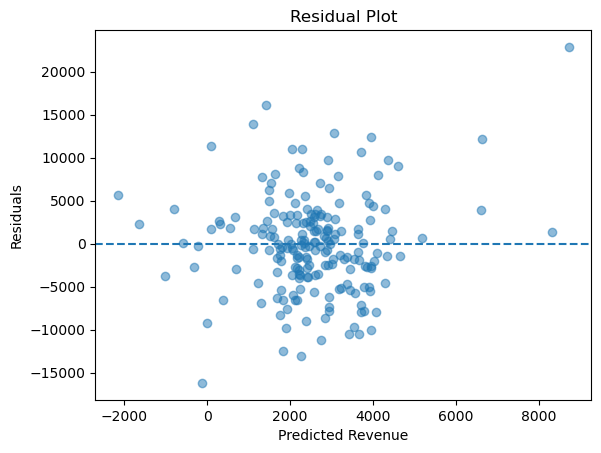

In [42]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [43]:
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
})

coef_df.sort_values("coefficient", key=abs, ascending=False)

,feature,coefficient
0,google_ads_spend_log,1145.256244
6,google_ads_spend_log_x_conversions,849.797725
7,email_marketing_spend_log_x_site_visits,510.395490
1,facebook_ads_spend_log,399.254706
2,conversions,130.051491
3,email_marketing_spend_log,125.164214
5,google_ads_spend_log_x_facebook_ads_spend_log,79.026075
4,site_visits,33.444083
8,google_ads_spend_log_cube,-13.138967


Model with less variables

In [44]:
features = [
    "google_ads_spend_log",
    "facebook_ads_spend_log",
    
    # best interaction terms
    "google_ads_spend_log_x_facebook_ads_spend_log",
    "google_ads_spend_log_x_conversions",
    "email_marketing_spend_log_x_site_visits",
    
    # optional nonlinear signal
    "google_ads_spend_log_cube"
]

X = df[features]
y = df["revenue"]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 31360663.90859945
R²: 0.10388852794829906


Refined model

In [48]:
corrs = df.corr()["revenue"].drop("revenue")

selected = corrs[abs(corrs) > 0.08].index.tolist()
selected

['google_ads_spend_log',
 'facebook_ads_spend_log',
 'google_ads_spend_log_sq',
 'google_ads_spend_log_cube',
 'facebook_ads_spend_log_cube',
 'google_ads_spend_log_x_facebook_ads_spend_log',
 'google_ads_spend_log_x_conversions',
 'google_ads_spend_log_roll1',
 'google_ads_spend_log_roll2',
 'google_ads_spend_log_roll3',
 'google_ads_spend_log_roll4',
 'google_ads_spend_log_roll5',
 'google_ads_spend_log_roll6',
 'google_ads_spend_log_roll7',
 'facebook_ads_spend_log_roll1',
 'facebook_ads_spend_log_roll2',
 'facebook_ads_spend_log_roll3',
 'facebook_ads_spend_log_roll4',
 'facebook_ads_spend_log_roll5',
 'facebook_ads_spend_log_roll6',
 'facebook_ads_spend_log_roll7']

In [49]:
import numpy as np

corr_matrix = df[selected].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

X_filtered = df[selected].drop(columns=to_drop)

In [50]:
X_filtered_nomissing = X_filtered[["google_ads_spend_log", "facebook_ads_spend_log", "google_ads_spend_log_sq",	"google_ads_spend_log_cube",	
               "facebook_ads_spend_log_cube", "google_ads_spend_log_x_facebook_ads_spend_log", "google_ads_spend_log_x_conversions"]]

In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(X):
    X_const = sm.add_constant(X)
    vif_data = pd.DataFrame({
        "feature": X_const.columns,
        "VIF": [variance_inflation_factor(X_const.values, i)
                for i in range(X_const.shape[1])]
    })
    return vif_data

compute_vif(X_filtered_nomissing)

,feature,VIF
0,const,1.321443
1,google_ads_spend_log,1.936346
2,facebook_ads_spend_log,1.833430
3,google_ads_spend_log_sq,1.370357
4,google_ads_spend_log_cube,2.138104
5,facebook_ads_spend_log_cube,1.820259
6,google_ads_spend_log_x_facebook_ads_spend_log,1.249085
7,google_ads_spend_log_x_conversions,1.126553


In [52]:
X_filtered[['google_ads_spend_log', 'google_ads_spend_log_roll2']].corr()

,google_ads_spend_log,google_ads_spend_log_roll2
google_ads_spend_log,1.000000,0.740858
google_ads_spend_log_roll2,0.740858,1.000000


In [53]:
X_filtered[['facebook_ads_spend_log', 'facebook_ads_spend_log_roll2']].corr()

,facebook_ads_spend_log,facebook_ads_spend_log_roll2
facebook_ads_spend_log,1.000000,0.723058
facebook_ads_spend_log_roll2,0.723058,1.000000


Simple model for each identified feature of value

In [54]:
y = df[['revenue']]   # or however you stored it
X = X_filtered        # your features

results = []

for col in X.columns:
    X_temp = sm.add_constant(X[[col]])
    model = sm.OLS(y, X_temp).fit()
    
    results.append({
        "feature": col,
        "r2": model.rsquared,
        "pval": model.pvalues.iloc[1]
    })

pd.DataFrame(results).sort_values("r2", ascending=False).head(10)

,feature,r2,pval
0,google_ads_spend_log,0.047536,3.677498e-12
3,google_ads_spend_log_cube,0.046223,7.382561e-12
7,google_ads_spend_log_roll2,0.020297,6.510415e-06
2,google_ads_spend_log_sq,0.019453,1.017780e-05
1,facebook_ads_spend_log,0.015987,6.405833e-05
5,google_ads_spend_log_x_facebook_ads_spend_log,0.009149,2.538482e-03
6,google_ads_spend_log_x_conversions,0.007607,5.930462e-03
4,facebook_ads_spend_log_cube,0.007398,6.659005e-03
8,facebook_ads_spend_log_roll2,0.007093,7.892706e-03


Stepwise evaluation

In [55]:
feature_sets = [
    ["google_ads_spend_log"],
    ["google_ads_spend_log", "facebook_ads_spend_log"],
    ["google_ads_spend_log", "facebook_ads_spend_log",
     "google_ads_spend_log_x_facebook_ads_spend_log"],
]

for feats in feature_sets:
    X = df[feats]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
    
    model = LinearRegression().fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(feats)
    print("R2:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("-----")

['google_ads_spend_log']
R2: 0.07174847360376735
MSE: 30813378.792410113
-----
['google_ads_spend_log', 'facebook_ads_spend_log']
R2: 0.09351147759448308
MSE: 30090954.248461224
-----
['google_ads_spend_log', 'facebook_ads_spend_log', 'google_ads_spend_log_x_facebook_ads_spend_log']
R2: 0.09986525982135441
MSE: 29880039.972584773
-----


Forward selection/backwards elimination

In [56]:
X = df[features]
y = df["revenue"]

In [57]:
X = X.dropna()

In [58]:
import statsmodels.api as sm

def forward_selection(X, y):
    remaining = list(X.columns)
    selected = []
    current_score = float("inf")
    
    while remaining:
        scores = []
        
        for candidate in remaining:
            features = selected + [candidate]
            X_model = sm.add_constant(X[features])
            model = sm.OLS(y, X_model).fit()
            scores.append((model.aic, candidate))
        
        scores.sort()
        best_score, best_candidate = scores[0]
        
        if best_score < current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_score
        else:
            break
            
    return selected

forward_features = forward_selection(X, y)
forward_features

['google_ads_spend_log',
 'facebook_ads_spend_log',
 'google_ads_spend_log_x_facebook_ads_spend_log',
 'email_marketing_spend_log_x_site_visits',
 'google_ads_spend_log_x_conversions',
 'google_ads_spend_log_cube']

In [59]:
X[['google_ads_spend_log', 'google_ads_spend_log_cube']].corr()

,google_ads_spend_log,google_ads_spend_log_cube
google_ads_spend_log,1.000000,0.685649
google_ads_spend_log_cube,0.685649,1.000000


In [60]:
def backward_elimination(X, y):
    features = list(X.columns)
    
    while len(features) > 0:
        X_model = sm.add_constant(X[features])
        model = sm.OLS(y, X_model).fit()
        
        pvalues = model.pvalues.iloc[1:]  # drop intercept
        worst_pval = pvalues.max()
        
        if worst_pval > 0.05:
            worst_feature = pvalues.idxmax()
            features.remove(worst_feature)
        else:
            break
            
    return features

backward_features = backward_elimination(X, y)
backward_features

['google_ads_spend_log',
 'facebook_ads_spend_log',
 'google_ads_spend_log_x_facebook_ads_spend_log',
 'google_ads_spend_log_x_conversions',
 'email_marketing_spend_log_x_site_visits']

Full model with identified features

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

candidate_features = ['google_ads_spend_log',
 'facebook_ads_spend_log',
 'google_ads_spend_log_x_facebook_ads_spend_log',
 'google_ads_spend_log_x_conversions',
 'email_marketing_spend_log_x_site_visits']

X = df[candidate_features]
y = df["revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# sklearn model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("Coefficients:", dict(zip(candidate_features, lr.coef_)))

# statsmodels for p-values
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

R2: 0.10620492030262096
MSE: 31279598.545226727
Coefficients: {'google_ads_spend_log': np.float64(1118.1286891367868), 'facebook_ads_spend_log': np.float64(381.1843235305513), 'google_ads_spend_log_x_facebook_ads_spend_log': np.float64(79.63549967958845), 'google_ads_spend_log_x_conversions': np.float64(833.5988936337487), 'email_marketing_spend_log_x_site_visits': np.float64(509.47233138634545)}
                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     9.213
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.55e-08
Time:                        21:08:00   Log-Likelihood:                -7898.9
No. Observations:                 795   AIC:                         1.581e+04
Df Residuals:                     789   BIC:   

In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_sm = sm.add_constant(X)
vif_data = pd.DataFrame({
    "feature": X_sm.columns,
    "VIF": [variance_inflation_factor(X_sm.values, i) for i in range(X_sm.shape[1])]
})
print(vif_data)

                                         feature       VIF
0                                          const  1.028821
1                           google_ads_spend_log  1.017066
2                         facebook_ads_spend_log  1.012286
3  google_ads_spend_log_x_facebook_ads_spend_log  1.002741
4             google_ads_spend_log_x_conversions  1.006645
5        email_marketing_spend_log_x_site_visits  1.001252


Cross validation of same model

In [63]:
from sklearn.model_selection import cross_val_score
import numpy as np

lr = LinearRegression()
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='r2')
print("R² CV:", cv_scores)
print("Mean R² CV:", np.mean(cv_scores))

R² CV: [0.0672659  0.04184132 0.07643193 0.04202719 0.08961839]
Mean R² CV: 0.06343694376669198


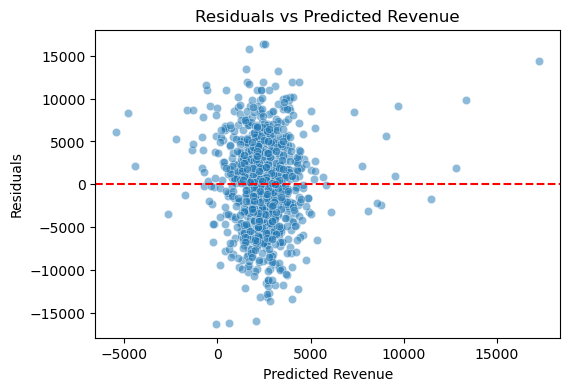

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Candidate features you mentioned
candidate_features = [
    'google_ads_spend_log',
    'facebook_ads_spend_log',
    'google_ads_spend_log_x_facebook_ads_spend_log',
    'email_marketing_spend_log_x_site_visits',
    'google_ads_spend_log_x_conversions',
    'google_ads_spend_log_cube'
]

X = df[candidate_features]
y = df['revenue']

# 1️⃣ Fit the model
lr = LinearRegression()
lr.fit(X, y)

# 2️⃣ Predict
y_pred = lr.predict(X)

# 3️⃣ Compute residuals
residuals = y - y_pred

# 4️⃣ Residual plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Revenue")
plt.show()

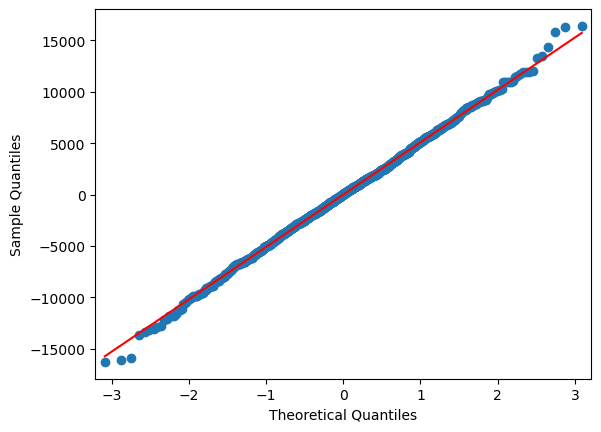

In [65]:
sm.qqplot(residuals, line='s')
plt.show()

In [66]:
import numpy as np
feature_contrib = pd.DataFrame({
    "feature": candidate_features,
    "coef": lr.coef_,
    "abs_coef": np.abs(lr.coef_)
}).sort_values("abs_coef", ascending=False)

print(feature_contrib)

                                         feature        coef    abs_coef
0                           google_ads_spend_log  906.386121  906.386121
1                         facebook_ads_spend_log  607.500855  607.500855
3        email_marketing_spend_log_x_site_visits  563.980238  563.980238
4             google_ads_spend_log_x_conversions  524.178244  524.178244
2  google_ads_spend_log_x_facebook_ads_spend_log  470.589599  470.589599
5                      google_ads_spend_log_cube  102.406681  102.406681


Best combination model

In [67]:
from itertools import combinations

best_adj_r2 = -np.inf
best_combo = None

for k in range(1, len(candidate_features)+1):
    for combo in combinations(candidate_features, k):
        X_temp = sm.add_constant(df[list(combo)])
        model = sm.OLS(y, X_temp).fit()
        if model.rsquared_adj > best_adj_r2:
            best_adj_r2 = model.rsquared_adj
            best_combo = combo

print("Best features:", best_combo)
print("Adj R²:", best_adj_r2)

Best features: ('google_ads_spend_log', 'facebook_ads_spend_log', 'google_ads_spend_log_x_facebook_ads_spend_log', 'email_marketing_spend_log_x_site_visits', 'google_ads_spend_log_x_conversions', 'google_ads_spend_log_cube')
Adj R²: 0.07376891920236284
